# 🚀 Image Classification on CIFAR-10 Using a Convolutional Neural Network (CNN)

### 📌 Project Overview
This notebook focuses on building and training a **Deep Convolutional Neural Network (CNN)** to automatically classify images. We use the classic **CIFAR-10 dataset** for this task. The goal is to train a model that can look at a tiny image and correctly predict its category.

---

### 📊 About the Dataset
The CIFAR-10 dataset is a widely used benchmark in machine learning.

* **Total Images:** 60,000 low-resolution color images.
* **Image Size:** 32x32 pixels with 3 color channels (RGB).
* **Dataset Split:** 50,000 images for training and 10,000 images for testing.
* **Classes:** There are 10 distinct classes, with exactly 6,000 images per class.

#### 🏷️ The 10 Categories:
* ✈️ Airplane
* 🚗 Automobile
* 🐦 Bird
* 🐱 Cat
* 🦌 Deer
* 🐶 Dog
* 🐸 Frog
* 🐴 Horse
* 🚢 Ship
* 🚚 Truck

---

### 🛠️ Workflow Steps
We will follow these steps to build our deep learning pipeline:

1. **Setup Environment:** Enable Google Colab's GPU acceleration to speed up training.
2. **Load Data:** Import the dataset using deep learning libraries like TensorFlow/Keras or PyTorch.
3. **Data Preprocessing:** Normalize pixel values down to a 0 to 1 range for smoother learning.
4. **Build CNN Architecture:** Create a stack of convolutional layers, pooling layers, and fully connected dense layers.
5. **Compile Model:** Define the loss function, select an optimizer, and choose evaluation metrics.
6. **Train & Validate:** Train the neural network over multiple epochs while tracking training and validation accuracy.
7. **Evaluate Performance:** Test the final model on unseen data and plot the accuracy curves.

---


In [1]:
import torch
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),  #Randomly flip images
    transforms.RandomCrop(32, padding=4),  #Random crop with padding
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2471, 0.2435, 0.2616])
])


## Download and load the training and testing data
train_images = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_images = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

#Create the data loaders
train_loader = torch.utils.data.DataLoader(train_images, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_images, batch_size=64, shuffle=False)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

epochs = 30

100%|██████████| 170M/170M [00:14<00:00, 12.1MB/s]


##Convolution Neural Network

In [2]:
import torch
import torch.nn.functional as F
import torch.optim as optim

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

class CNN(torch.nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # First convolutional block
        self.conv1 = torch.nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = torch.nn.BatchNorm2d(32)
        self.conv2 = torch.nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = torch.nn.BatchNorm2d(32)
        self.pool1 = torch.nn.MaxPool2d(2, 2)  # 32x32 -> 16x16

        # Second convolutional block
        self.conv3 = torch.nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = torch.nn.BatchNorm2d(64)
        self.conv4 = torch.nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = torch.nn.BatchNorm2d(64)
        self.pool2 = torch.nn.MaxPool2d(2, 2)  # 16x16 -> 8x8

        # Third convolutional block
        self.conv5 = torch.nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn5 = torch.nn.BatchNorm2d(128)
        self.conv6 = torch.nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn6 = torch.nn.BatchNorm2d(128)
        self.pool3 = torch.nn.MaxPool2d(2, 2)  # 8x8 -> 4x4

        # Fully connected layers
        self.fc1 = torch.nn.Linear(128 * 4 * 4, 256)
        self.dropout1 = torch.nn.Dropout(0.5)
        self.fc2 = torch.nn.Linear(256, 128)
        self.dropout2 = torch.nn.Dropout(0.5)
        self.fc3 = torch.nn.Linear(128, 10)

    def forward(self, x):
        # Block 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)

        # Block 2
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)

        # Block 3
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.pool3(x)

        # Fully connected
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

model = CNN().to(device)

Using cuda device


In [3]:
loss_function = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [4]:
model.train()

epochs = epochs
for epoch in range(epochs):
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(images) # 1. Forward Pass
        loss = loss_function(output, labels)  # 2. Calculate Loss
        loss.backward()  # 3. Backward Pass
        optimizer.step() # 4. Optimizer Step
        running_loss += loss.item()
    print(f"Epoch {epoch+1} - Training loss: {running_loss/len(train_loader)}")

Epoch 1 - Training loss: 1.7411013338571923
Epoch 2 - Training loss: 1.3376176755903932
Epoch 3 - Training loss: 1.1510694213687915
Epoch 4 - Training loss: 1.032908677597485
Epoch 5 - Training loss: 0.9555540846284393
Epoch 6 - Training loss: 0.8866518153558911
Epoch 7 - Training loss: 0.8301140940783883
Epoch 8 - Training loss: 0.7825270187290733
Epoch 9 - Training loss: 0.7420446912345984
Epoch 10 - Training loss: 0.6957904060021081
Epoch 11 - Training loss: 0.6690538507669478
Epoch 12 - Training loss: 0.642842455745658
Epoch 13 - Training loss: 0.6172086566381747
Epoch 14 - Training loss: 0.5862497983076383
Epoch 15 - Training loss: 0.5650197245428324
Epoch 16 - Training loss: 0.5448142854720736
Epoch 17 - Training loss: 0.5261758613731246
Epoch 18 - Training loss: 0.513716936492554
Epoch 19 - Training loss: 0.4980012069806418
Epoch 20 - Training loss: 0.48172524315126414
Epoch 21 - Training loss: 0.46699863548397713
Epoch 22 - Training loss: 0.452188627227493
Epoch 23 - Training l

In [5]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

test(test_loader, model, loss_function)

Test Error: 
 Accuracy: 85.8%, Avg loss: 0.429880 



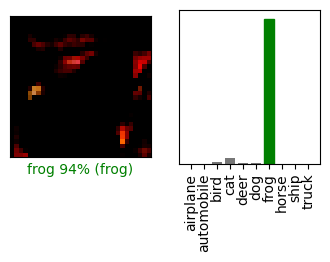

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt

image_id = 30 # Pick an image id between 0 and 9999 inclusive

# Get a batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

img = images[image_id].to(device)
true_label = labels[image_id].to(device)

# Make a prediction
with torch.no_grad(): # Inference mode
    logits = model(img.unsqueeze(0))

ps = torch.nn.functional.softmax(logits, dim=1).cpu()
predictions = ps.numpy()[0]
predicted_label = np.argmax(predictions)

def plot_image(predictions_array, true_label, img):
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    img_display = np.clip(img.cpu().numpy().transpose((1, 2, 0)), 0, 1)

    plt.imshow(img_display)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'green'
    else:
        color = 'red'

    plt.xlabel(f"{class_names[predicted_label]} {100*np.max(predictions_array):2.0f}% ({class_names[true_label]})", color=color)

def plot_value_array(predictions_array, true_label):
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)

    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('green')

plt.figure(figsize=(4,2))
plt.subplot(1,2,1)
plot_image(predictions, true_label.item(), img)
plt.subplot(1,2,2)
plot_value_array(predictions, true_label.item())
_ = plt.xticks(range(10), class_names, rotation=90)
plt.show()